Libraries Import

In [ ]:
import pandas as pd
import numpy as np

Dataset Load

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")

Finding Missing Values

In [ ]:
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


 Add Missing Values in Age

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())

Add Embarked Missing Values

In [ ]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

Create new Column of name CabinKnown

In [ ]:
df["CabinKnown"] = df["Cabin"].notna().astype(int)

Remove Cabin Column

In [ ]:
df.drop("Cabin", axis=1, inplace=True)

Create FamilySize Column

In [ ]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

Create IsAlone Column

In [ ]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

After Cleaning Check Missing Values

In [ ]:
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
CabinKnown     0
FamilySize     0
IsAlone        0
dtype: int64


See Cleaned Dataset

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,CabinKnown,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,1,1


Check the cleaned dataset

In [ ]:
print(df.shape)
print(df.isnull().sum())
df.head()

(891, 14)
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
CabinKnown     0
FamilySize     0
IsAlone        0
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,CabinKnown,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,1,1


Perform Outlier Detection

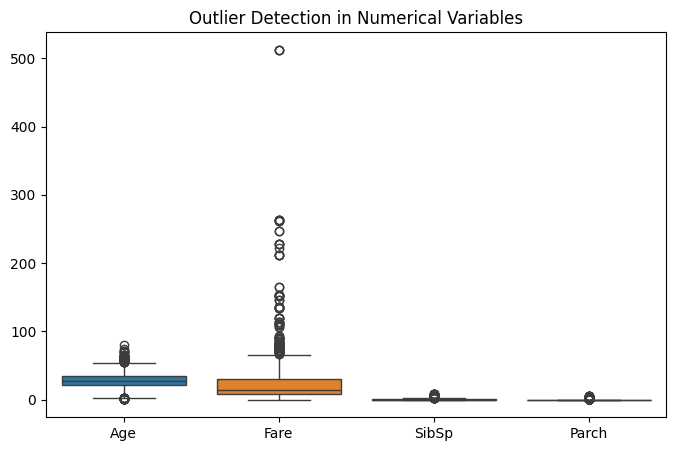

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(data=df[["Age", "Fare", "SibSp", "Parch"]])
plt.title("Outlier Detection in Numerical Variables")
plt.show()

Create Basic Visualizations

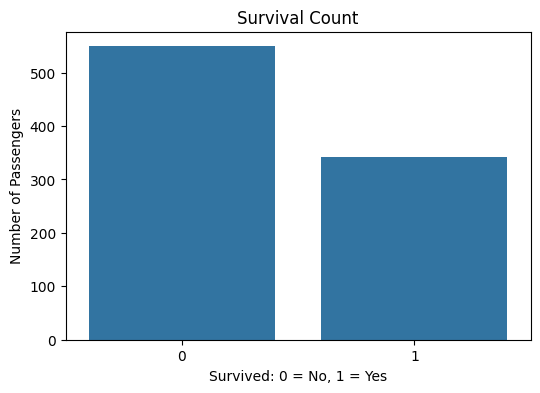

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.xlabel("Survived: 0 = No, 1 = Yes")
plt.ylabel("Number of Passengers")
plt.show()

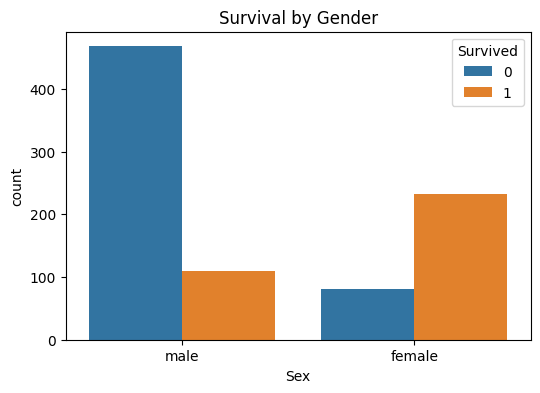

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

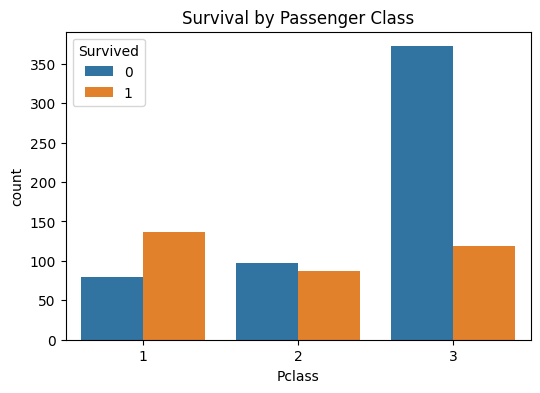

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

Generate Summary Statistics

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,CabinKnown,FamilySize,IsAlone
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208,0.228956,1.904602,0.602694
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429,0.420397,1.613459,0.489615
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000,1.000000,0.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000,1.000000,1.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,0.000000,2.000000,1.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,11.000000,1.000000
